<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [ ]:
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the data


In [4]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Display the first few rows of the data to understand its structure


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



,JobSatPoints_6,JobSatPoints_7
Age,,
Under 18 years old,1.5,5.0
18-24 years old,15.0,20.0
25-34 years old,20.0,15.0
35-44 years old,20.0,15.0
45-54 years old,20.0,15.0
55-64 years old,20.0,20.0
65 years or older,20.0,15.0


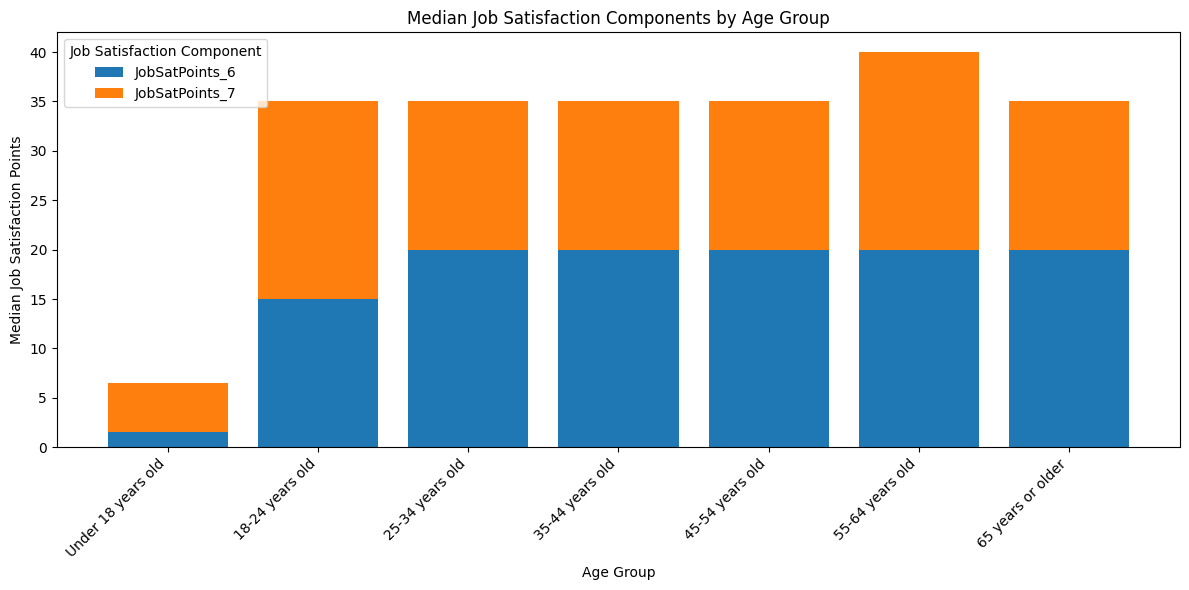

In [6]:
# Task 1.1 - Median Job Satisfaction Components by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

age_sat = df[["Age", "JobSatPoints_6", "JobSatPoints_7"]].copy()

age_sat["JobSatPoints_6"] = pd.to_numeric(
    age_sat["JobSatPoints_6"], errors="coerce"
)
age_sat["JobSatPoints_7"] = pd.to_numeric(
    age_sat["JobSatPoints_7"], errors="coerce"
)

age_sat = age_sat[
    age_sat["Age"].isin(age_order)
]

age_sat_summary = (
    age_sat
    .groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
    .reindex(age_order)
    .dropna(how="all")
)

display(age_sat_summary.round(2))

x = np.arange(len(age_sat_summary))
bottom = np.zeros(len(age_sat_summary))

plt.figure(figsize=(12, 6))

for column in ["JobSatPoints_6", "JobSatPoints_7"]:
    values = age_sat_summary[column].fillna(0).to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=column
    )
    bottom += values

plt.xticks(
    x,
    age_sat_summary.index,
    rotation=45,
    ha="right"
)

plt.title("Median Job Satisfaction Components by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction Points")
plt.legend(title="Job Satisfaction Component")
plt.tight_layout()
plt.show()


#### Analysis

This stacked chart compares the median values of `JobSatPoints_6` and `JobSatPoints_7` across the survey's age categories. Using the median reduces the influence of unusually high or low responses and provides a more representative view of the typical value within each age group.

The total height of each stacked bar reflects the combined magnitude of these two job-satisfaction components, while the individual segments show how much each component contributes within a given age category. Differences in segment size across age groups can indicate that specific aspects of job satisfaction vary by career stage.

The age variable is categorical rather than continuous. Therefore, the chart compares age groups and should not be interpreted as showing exact changes for every year of age. In addition, `JobSatPoints_6` and `JobSatPoints_7` are individual components of the survey's job-satisfaction measurement; their stacked total is useful for comparison but should not be treated as a new overall satisfaction score.


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


,JobSatPoints_6,JobSatPoints_7
EmploymentType,,
"Not employed, and not looking for work",10.0,10.0
"Not employed, but looking for work",10.0,10.0
Retired,10.0,11.0
"Student, full-time",10.0,15.0
"Employed, part-time",15.0,15.0
"Independent contractor, freelancer, or self-employed",15.0,15.0
"Employed, full-time",20.0,15.0
"Student, part-time",15.0,20.0


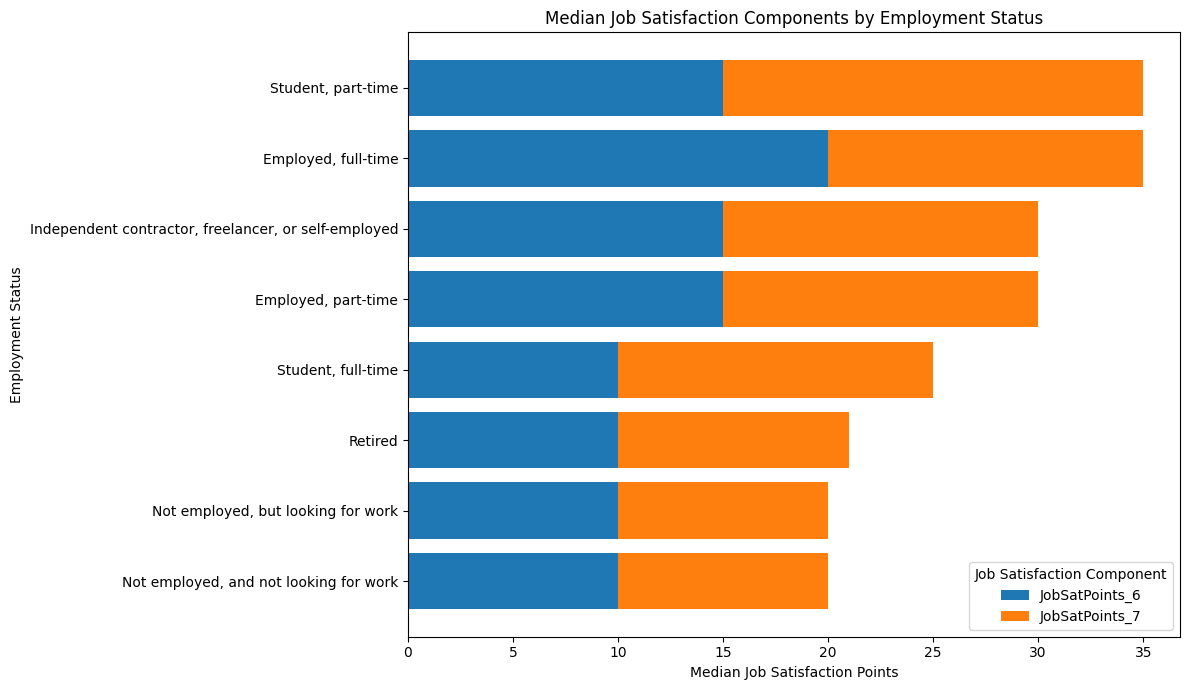

In [7]:
# Task 1.2 - Job Satisfaction Components by Employment Status

employment_sat = df[
    ["Employment", "JobSatPoints_6", "JobSatPoints_7"]
].copy()

employment_sat["JobSatPoints_6"] = pd.to_numeric(
    employment_sat["JobSatPoints_6"], errors="coerce"
)
employment_sat["JobSatPoints_7"] = pd.to_numeric(
    employment_sat["JobSatPoints_7"], errors="coerce"
)

# Employment can contain multiple selections separated by semicolons.
employment_sat["EmploymentType"] = (
    employment_sat["Employment"]
    .str.split(";")
)

employment_sat = employment_sat.explode(
    "EmploymentType",
    ignore_index=True
)

employment_sat["EmploymentType"] = (
    employment_sat["EmploymentType"]
    .str.strip()
)

employment_sat = employment_sat.dropna(
    subset=["EmploymentType"]
)

# Keep the most common statuses so the chart remains readable.
top_employment = (
    employment_sat["EmploymentType"]
    .value_counts()
    .head(8)
    .index
)

employment_sat = employment_sat[
    employment_sat["EmploymentType"].isin(top_employment)
]

employment_summary = (
    employment_sat
    .groupby("EmploymentType")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
)

employment_summary["CombinedMedian"] = employment_summary.sum(axis=1)
employment_summary = employment_summary.sort_values(
    "CombinedMedian",
    ascending=True
)

display(
    employment_summary[
        ["JobSatPoints_6", "JobSatPoints_7"]
    ].round(2)
)

y = np.arange(len(employment_summary))
left = np.zeros(len(employment_summary))

plt.figure(figsize=(12, 7))

for column in ["JobSatPoints_6", "JobSatPoints_7"]:
    values = employment_summary[column].fillna(0).to_numpy()
    plt.barh(
        y,
        values,
        left=left,
        label=column
    )
    left += values

plt.yticks(y, employment_summary.index)
plt.title("Median Job Satisfaction Components by Employment Status")
plt.xlabel("Median Job Satisfaction Points")
plt.ylabel("Employment Status")
plt.legend(title="Job Satisfaction Component")
plt.tight_layout()
plt.show()


#### Analysis

The chart compares two job-satisfaction components across the most common employment statuses. Horizontal stacked bars are used because employment labels are relatively long, making the categories easier to read.

Differences in the total bar length indicate that the typical combined magnitude of `JobSatPoints_6` and `JobSatPoints_7` varies across employment situations. Differences in the relative size of the two segments can also reveal whether one satisfaction component contributes more strongly for a particular employment group.

`Employment` is a multi-response field, so one respondent may contribute to more than one employment category. For that reason, the categories are not mutually exclusive and the chart should be interpreted as a comparison of employment-status selections rather than a partition of unique respondents. The visualization is descriptive and does not establish that employment status causes differences in job satisfaction.


### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


,ConvertedCompYearly,JobSatPoints_6
Age,,
25-34 years old,59825.0,20.0
35-44 years old,84796.0,20.0


,Compensation Index,Satisfaction Index
Age,,
25-34 years old,70.55,100.0
35-44 years old,100.00,100.0


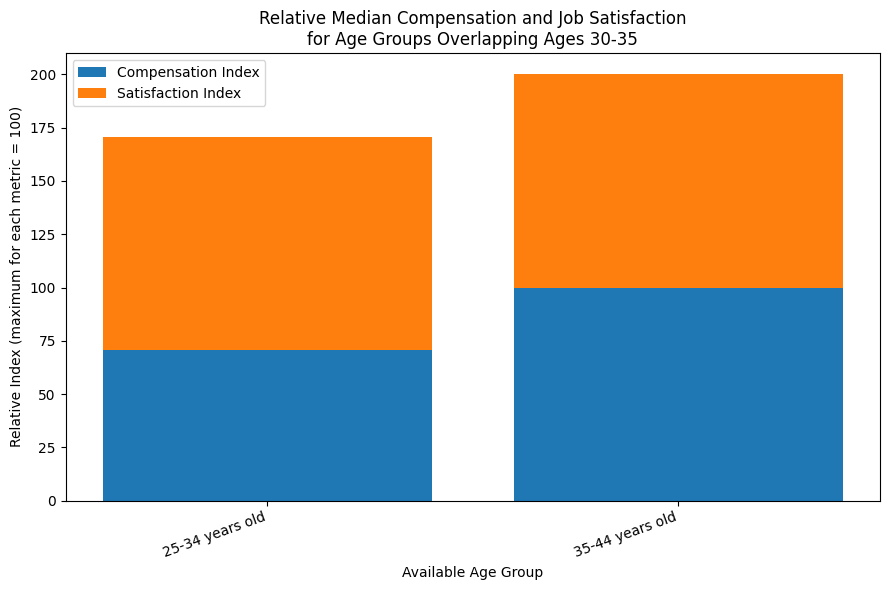

In [8]:
# Task 2.1 - Compensation and Job Satisfaction for the Age Range 30-35

# The dataset stores Age in ranges rather than exact ages.
# The closest available categories overlapping ages 30-35 are 25-34 and 35-44.
target_age_groups = [
    "25-34 years old",
    "35-44 years old"
]

age_30_35 = df[
    ["Age", "ConvertedCompYearly", "JobSatPoints_6"]
].copy()

age_30_35["ConvertedCompYearly"] = pd.to_numeric(
    age_30_35["ConvertedCompYearly"], errors="coerce"
)
age_30_35["JobSatPoints_6"] = pd.to_numeric(
    age_30_35["JobSatPoints_6"], errors="coerce"
)

age_30_35 = age_30_35[
    age_30_35["Age"].isin(target_age_groups)
]

raw_summary = (
    age_30_35
    .groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]]
    .median()
    .reindex(target_age_groups)
)

display(raw_summary.round(2))

# Raw compensation and satisfaction use incompatible units.
# Convert each metric to a relative index where its maximum equals 100.
indexed_summary = raw_summary.copy()

for column in ["ConvertedCompYearly", "JobSatPoints_6"]:
    max_value = indexed_summary[column].max()
    indexed_summary[column] = (
        indexed_summary[column] / max_value * 100
        if pd.notna(max_value) and max_value != 0
        else np.nan
    )

indexed_summary = indexed_summary.rename(
    columns={
        "ConvertedCompYearly": "Compensation Index",
        "JobSatPoints_6": "Satisfaction Index"
    }
)

display(indexed_summary.round(2))

x = np.arange(len(indexed_summary))
bottom = np.zeros(len(indexed_summary))

plt.figure(figsize=(9, 6))

for column in indexed_summary.columns:
    values = indexed_summary[column].fillna(0).to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=column
    )
    bottom += values

plt.xticks(
    x,
    indexed_summary.index,
    rotation=20,
    ha="right"
)

plt.title(
    "Relative Median Compensation and Job Satisfaction\n"
    "for Age Groups Overlapping Ages 30-35"
)
plt.xlabel("Available Age Group")
plt.ylabel("Relative Index (maximum for each metric = 100)")
plt.legend()
plt.tight_layout()
plt.show()


#### Analysis

The survey does not provide exact ages, so respondents aged exactly 30-35 cannot be isolated. The two available categories that overlap the requested interval are `25-34 years old` and `35-44 years old`. The visualization therefore provides an approximation rather than an exact 30-35 cohort.

Yearly compensation and job-satisfaction points are measured in fundamentally different units. Stacking the raw values would make the satisfaction segment almost invisible because compensation is measured in currency. To avoid a misleading chart, both medians are converted to relative indices in which the highest value of each metric among the selected age groups equals 100.

The stacked chart should therefore be interpreted as a comparison of **relative levels**, not as a literal combined amount. A larger compensation index indicates a higher median yearly compensation relative to the other overlapping age group, while a larger satisfaction index indicates a higher median `JobSatPoints_6`. The chart can suggest whether compensation and this satisfaction component move in the same or different directions, but it does not imply causation.


##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


,ConvertedCompYearly,JobSatPoints_6
Age,,
Under 18 years old,7626.5,1.5
18-24 years old,25000.0,15.0
25-34 years old,59825.0,20.0
35-44 years old,84796.0,20.0
45-54 years old,99099.0,20.0
55-64 years old,109691.0,20.0
65 years or older,106000.0,20.0


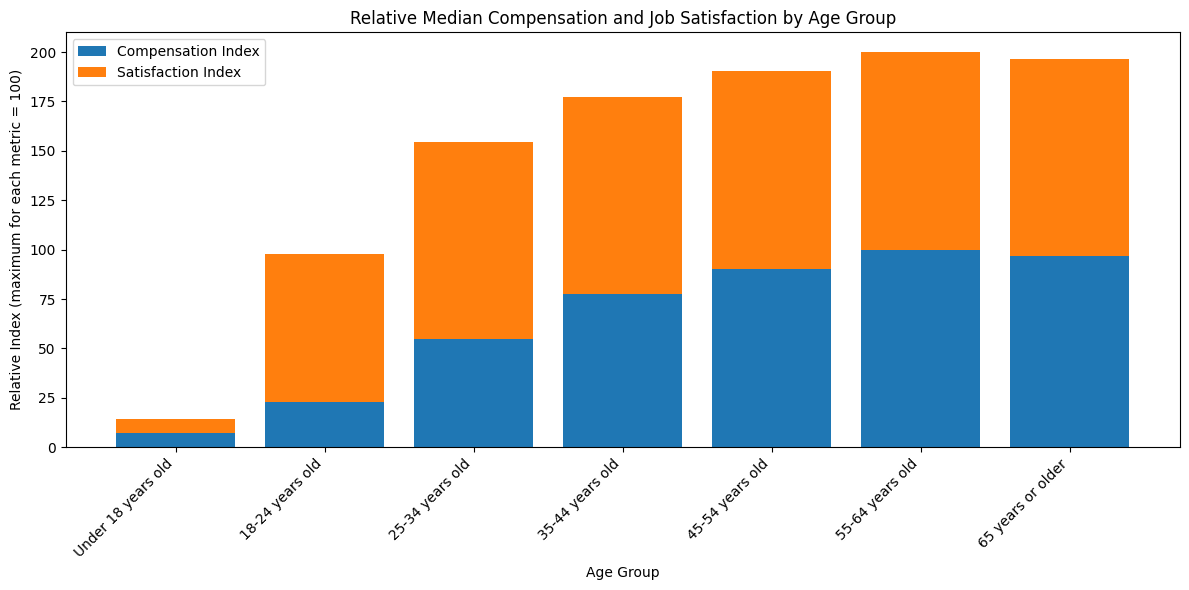

In [9]:
# Task 2.2 - Median Compensation and Job Satisfaction Across Age Groups

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

age_metrics = df[
    ["Age", "ConvertedCompYearly", "JobSatPoints_6"]
].copy()

age_metrics["ConvertedCompYearly"] = pd.to_numeric(
    age_metrics["ConvertedCompYearly"], errors="coerce"
)
age_metrics["JobSatPoints_6"] = pd.to_numeric(
    age_metrics["JobSatPoints_6"], errors="coerce"
)

age_metrics = age_metrics[
    age_metrics["Age"].isin(age_order)
]

raw_age_metrics = (
    age_metrics
    .groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]]
    .median()
    .reindex(age_order)
    .dropna(how="all")
)

display(raw_age_metrics.round(2))

# Normalize each measure independently for a meaningful stacked comparison.
indexed_age_metrics = raw_age_metrics.copy()

for column in ["ConvertedCompYearly", "JobSatPoints_6"]:
    max_value = indexed_age_metrics[column].max()
    indexed_age_metrics[column] = (
        indexed_age_metrics[column] / max_value * 100
        if pd.notna(max_value) and max_value != 0
        else np.nan
    )

indexed_age_metrics = indexed_age_metrics.rename(
    columns={
        "ConvertedCompYearly": "Compensation Index",
        "JobSatPoints_6": "Satisfaction Index"
    }
)

x = np.arange(len(indexed_age_metrics))
bottom = np.zeros(len(indexed_age_metrics))

plt.figure(figsize=(12, 6))

for column in indexed_age_metrics.columns:
    values = indexed_age_metrics[column].fillna(0).to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=column
    )
    bottom += values

plt.xticks(
    x,
    indexed_age_metrics.index,
    rotation=45,
    ha="right"
)

plt.title("Relative Median Compensation and Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Relative Index (maximum for each metric = 100)")
plt.legend()
plt.tight_layout()
plt.show()


#### Analysis

This chart compares the age-group pattern of median `ConvertedCompYearly` with the pattern of median `JobSatPoints_6`. Because compensation and satisfaction use incompatible scales, each metric is converted to a relative index before stacking. The raw medians are displayed separately above the chart and should be used whenever exact values are needed.

The visualization is useful for determining whether age groups with relatively higher compensation also exhibit relatively higher values for this job-satisfaction component. A similar profile across age groups would suggest that the two measures tend to move together, whereas contrasting segment patterns would suggest that compensation and satisfaction follow different age-related trends.

Previous exploratory analysis of this dataset indicated that age has a clearer association with compensation than with job satisfaction. This stacked comparison is consistent with treating compensation and satisfaction as related but distinct outcomes influenced by multiple factors such as experience, role, country, employment conditions, and career stage.


### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


Database,PostgreSQL,SQLite,MySQL,MongoDB,Redis
Age,,,,,
Under 18 years old,25.20,25.30,20.47,18.63,10.41
18-24 years old,30.98,18.49,18.64,18.34,13.54
25-34 years old,34.27,17.62,16.07,15.70,16.34
35-44 years old,35.43,18.79,15.57,13.14,17.07
45-54 years old,35.18,20.66,17.98,12.35,13.82
55-64 years old,34.51,23.50,22.45,11.15,8.39
65 years or older,24.16,29.31,31.99,10.07,4.47


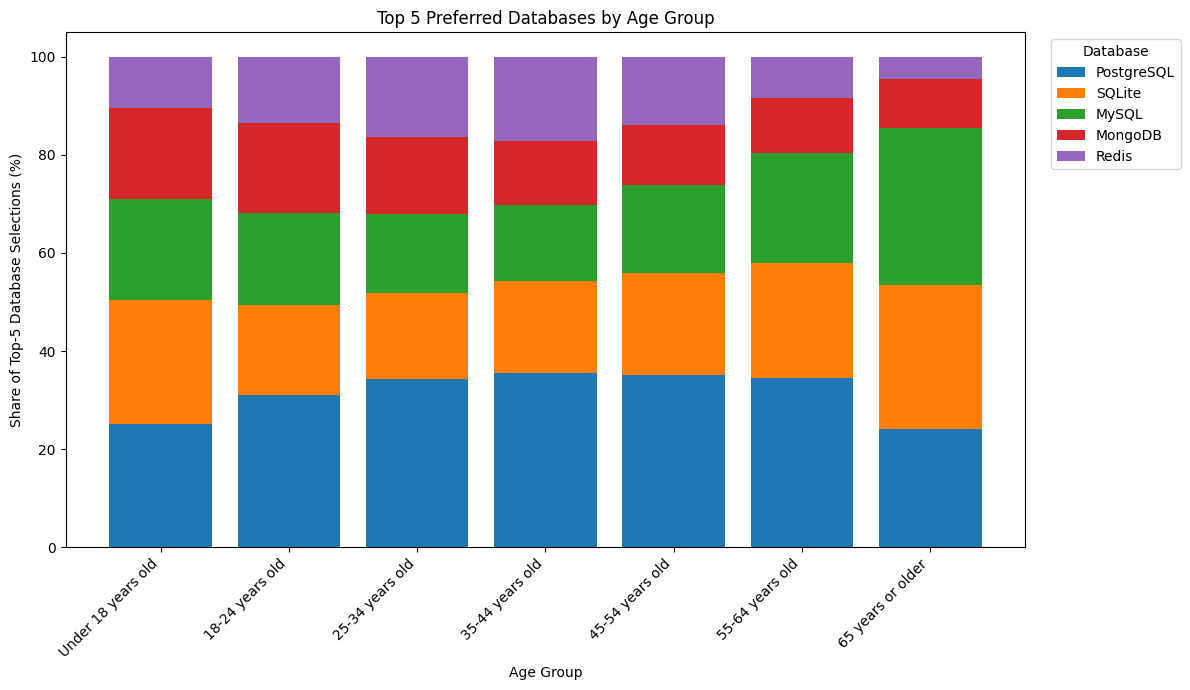

In [11]:
# Task 3.1 - Preferred Databases by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

database_age = df[
    ["Age", "DatabaseWantToWorkWith"]
].dropna().copy()

database_age = database_age[
    database_age["Age"].isin(age_order)
]

database_age["Database"] = (
    database_age["DatabaseWantToWorkWith"]
    .str.split(";")
)

database_age = database_age.explode(
    "Database",
    ignore_index=True
)

database_age["Database"] = (
    database_age["Database"]
    .str.strip()
)

# Use the five most frequently selected databases overall.
top_databases = (
    database_age["Database"]
    .value_counts()
    .head(5)
    .index
)

database_age = database_age[
    database_age["Database"].isin(top_databases)
]

database_counts = pd.crosstab(
    database_age["Age"],
    database_age["Database"]
).reindex(
    index=age_order,
    columns=top_databases,
    fill_value=0
)

database_pct = (
    database_counts
    .div(database_counts.sum(axis=1), axis=0)
    .mul(100)
    .fillna(0)
)

display(database_pct.round(2))

x = np.arange(len(database_pct))
bottom = np.zeros(len(database_pct))

plt.figure(figsize=(12, 7))

for database in database_pct.columns:
    values = database_pct[database].to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=database
    )
    bottom += values

plt.xticks(
    x,
    database_pct.index,
    rotation=45,
    ha="right"
)

plt.title("Top 5 Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Share of Top-5 Database Selections (%)")
plt.legend(
    title="Database",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


#### Analysis

The 100% stacked chart compares the composition of the five most frequently desired databases across age groups. Normalizing each age group to 100% prevents larger age groups from dominating the chart simply because they contain more respondents.

The width of each segment represents the share of **Top-5 database selections** associated with that age group. Similar segment proportions across age groups would indicate broad cross-generational interest, while noticeable changes in segment size would suggest that database preferences vary by age or career stage.

`DatabaseWantToWorkWith` is a multi-response field, so respondents may select several databases. Consequently, these percentages describe the composition of database selections rather than the percentage of unique respondents. The visualization is appropriate for comparing preference structure, but it should not be interpreted as a probability that an individual respondent chooses only one database.


##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


EmploymentType,"Employed, full-time","Independent contractor, freelancer, or self-employed","Employed, part-time","Student, full-time","Student, part-time"
JobSat,,,,,
1,73.64,11.21,8.48,3.03,3.64
2,75.46,11.07,5.86,2.82,4.78
3,75.78,10.44,6.09,3.77,3.92
4,74.13,12.31,6.41,3.24,3.91
5,76.76,11.73,5.84,2.88,2.79
6,76.89,11.02,5.63,3.36,3.11
7,77.78,11.50,5.23,3.13,2.36
8,76.98,12.52,4.96,2.89,2.66
9,77.56,13.20,4.58,2.46,2.20


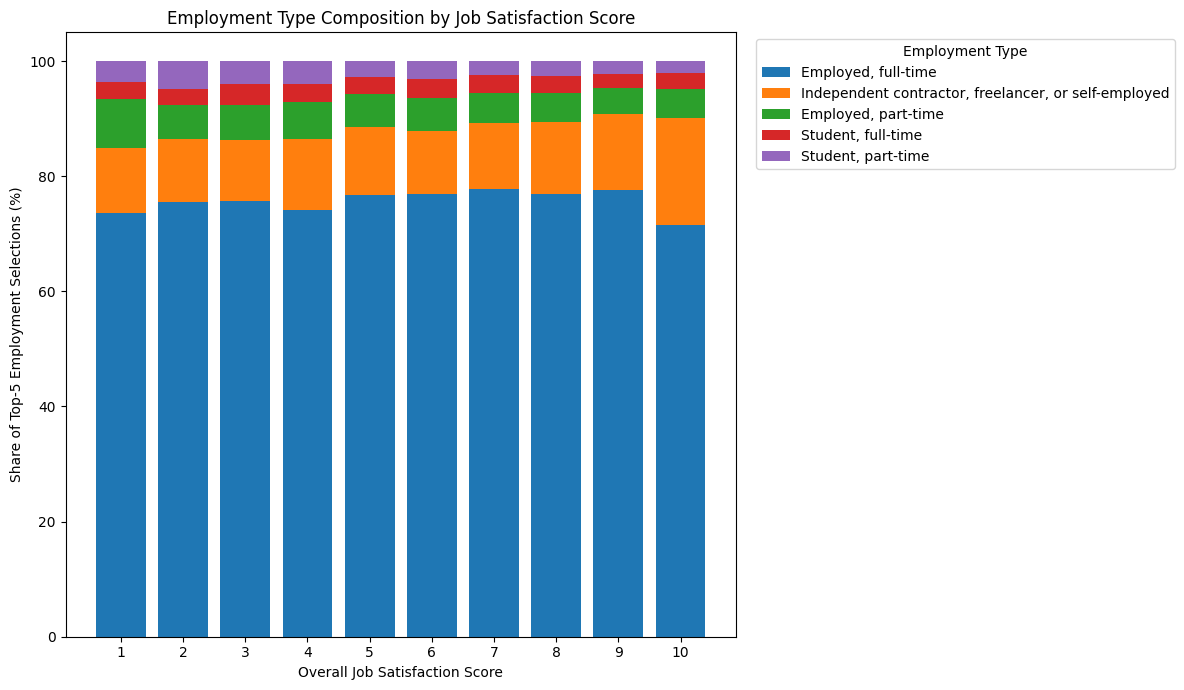

In [12]:
# Task 3.2 - Employment Type by Job Satisfaction

employment_job_sat = df[
    ["Employment", "JobSat"]
].copy()

employment_job_sat["JobSat"] = pd.to_numeric(
    employment_job_sat["JobSat"],
    errors="coerce"
)

employment_job_sat = employment_job_sat.dropna(
    subset=["Employment", "JobSat"]
)

employment_job_sat = employment_job_sat[
    employment_job_sat["JobSat"].between(1, 10)
]

employment_job_sat["JobSat"] = (
    employment_job_sat["JobSat"]
    .astype(int)
)

employment_job_sat["EmploymentType"] = (
    employment_job_sat["Employment"]
    .str.split(";")
)

employment_job_sat = employment_job_sat.explode(
    "EmploymentType",
    ignore_index=True
)

employment_job_sat["EmploymentType"] = (
    employment_job_sat["EmploymentType"]
    .str.strip()
)

top_employment = (
    employment_job_sat["EmploymentType"]
    .value_counts()
    .head(5)
    .index
)

employment_job_sat = employment_job_sat[
    employment_job_sat["EmploymentType"].isin(top_employment)
]

employment_counts = pd.crosstab(
    employment_job_sat["JobSat"],
    employment_job_sat["EmploymentType"]
).reindex(
    index=range(1, 11),
    columns=top_employment,
    fill_value=0
)

employment_pct = (
    employment_counts
    .div(employment_counts.sum(axis=1), axis=0)
    .mul(100)
    .fillna(0)
)

display(employment_pct.round(2))

x = np.arange(len(employment_pct))
bottom = np.zeros(len(employment_pct))

plt.figure(figsize=(12, 7))

for employment_type in employment_pct.columns:
    values = employment_pct[employment_type].to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=employment_type
    )
    bottom += values

plt.xticks(x, employment_pct.index)
plt.title("Employment Type Composition by Job Satisfaction Score")
plt.xlabel("Overall Job Satisfaction Score")
plt.ylabel("Share of Top-5 Employment Selections (%)")
plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


#### Analysis

This 100% stacked chart shows how the five most common employment-status selections are distributed within each overall `JobSat` score from 1 to 10. Using percentages rather than raw counts makes the composition comparable across satisfaction scores even when the number of respondents differs substantially between ratings.

Changes in segment proportions across the x-axis can reveal whether certain employment situations are relatively more common among respondents reporting low, moderate, or high job satisfaction. Stable proportions would suggest that employment composition changes little across satisfaction levels, whereas systematic shifts could motivate further investigation into employment conditions and satisfaction.

Because `Employment` can contain multiple selections, one respondent can contribute to more than one employment category. The chart is therefore a composition of employment selections within each satisfaction score and should not be interpreted as mutually exclusive workforce percentages or as evidence of a causal relationship.


### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


Language,JavaScript,Python,SQL,HTML/CSS,TypeScript
Age,,,,,
Under 18 years old,22.98,27.63,11.00,25.76,12.63
18-24 years old,21.51,23.46,18.22,20.58,16.23
25-34 years old,21.73,20.35,20.58,19.00,18.34
35-44 years old,22.63,18.59,22.17,20.09,16.52
45-54 years old,22.34,19.63,25.94,19.61,12.48
55-64 years old,22.61,20.45,28.37,19.74,8.83
65 years or older,21.94,25.03,26.32,21.81,4.90


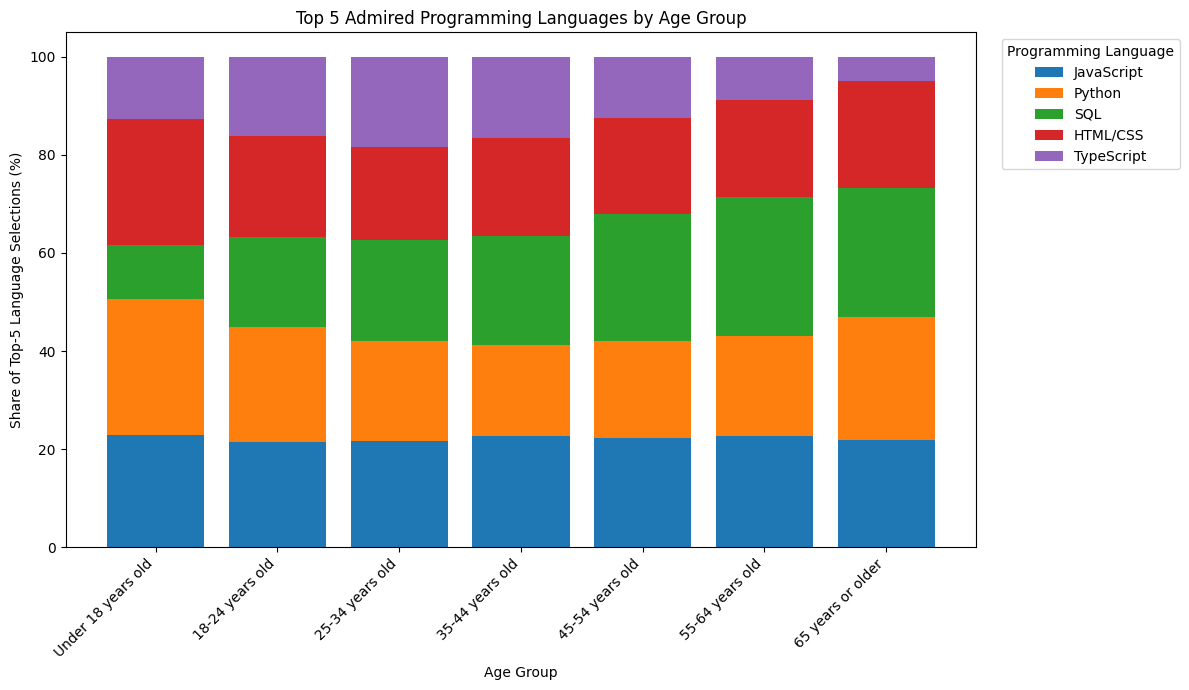

In [13]:
# Task 4.1 - Preferred Programming Languages by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

language_age = df[
    ["Age", "LanguageAdmired"]
].dropna().copy()

language_age = language_age[
    language_age["Age"].isin(age_order)
]

language_age["Language"] = (
    language_age["LanguageAdmired"]
    .str.split(";")
)

language_age = language_age.explode(
    "Language",
    ignore_index=True
)

language_age["Language"] = (
    language_age["Language"]
    .str.strip()
)

top_languages = (
    language_age["Language"]
    .value_counts()
    .head(5)
    .index
)

language_age = language_age[
    language_age["Language"].isin(top_languages)
]

language_counts = pd.crosstab(
    language_age["Age"],
    language_age["Language"]
).reindex(
    index=age_order,
    columns=top_languages,
    fill_value=0
)

language_pct = (
    language_counts
    .div(language_counts.sum(axis=1), axis=0)
    .mul(100)
    .fillna(0)
)

display(language_pct.round(2))

x = np.arange(len(language_pct))
bottom = np.zeros(len(language_pct))

plt.figure(figsize=(12, 7))

for language in language_pct.columns:
    values = language_pct[language].to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=language
    )
    bottom += values

plt.xticks(
    x,
    language_pct.index,
    rotation=45,
    ha="right"
)

plt.title("Top 5 Admired Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Share of Top-5 Language Selections (%)")
plt.legend(
    title="Programming Language",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


#### Analysis

The chart compares the composition of the five most frequently admired programming languages across age groups. By converting each age group's Top-5 selections to percentages, the visualization focuses on **preference mix** rather than the unequal number of respondents in each age category.

The main analytical signal is whether individual language segments remain similar or change noticeably as age increases. Similar proportions would indicate broad cross-generational appeal, while larger shifts could suggest cohort-specific technology preferences shaped by education, career history, or changes in the software ecosystem.

Because `LanguageAdmired` allows multiple selections, the percentages refer to language selections within the displayed Top 5 and not to unique respondents. The chart can identify patterns worth investigating, but it cannot determine why a particular age group admires one language more than another.


##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


Platform,Amazon Web Services (AWS),Microsoft Azure,Google Cloud,Cloudflare,Firebase
EmploymentType,,,,,
"Employed, full-time",41.01,22.90,16.82,11.01,8.26
"Independent contractor, freelancer, or self-employed",34.58,17.93,18.40,17.03,12.06
"Student, full-time",25.05,12.68,20.99,24.43,16.86
"Employed, part-time",31.64,17.91,19.83,17.77,12.84
"Not employed, but looking for work",34.75,12.62,20.45,15.77,16.42


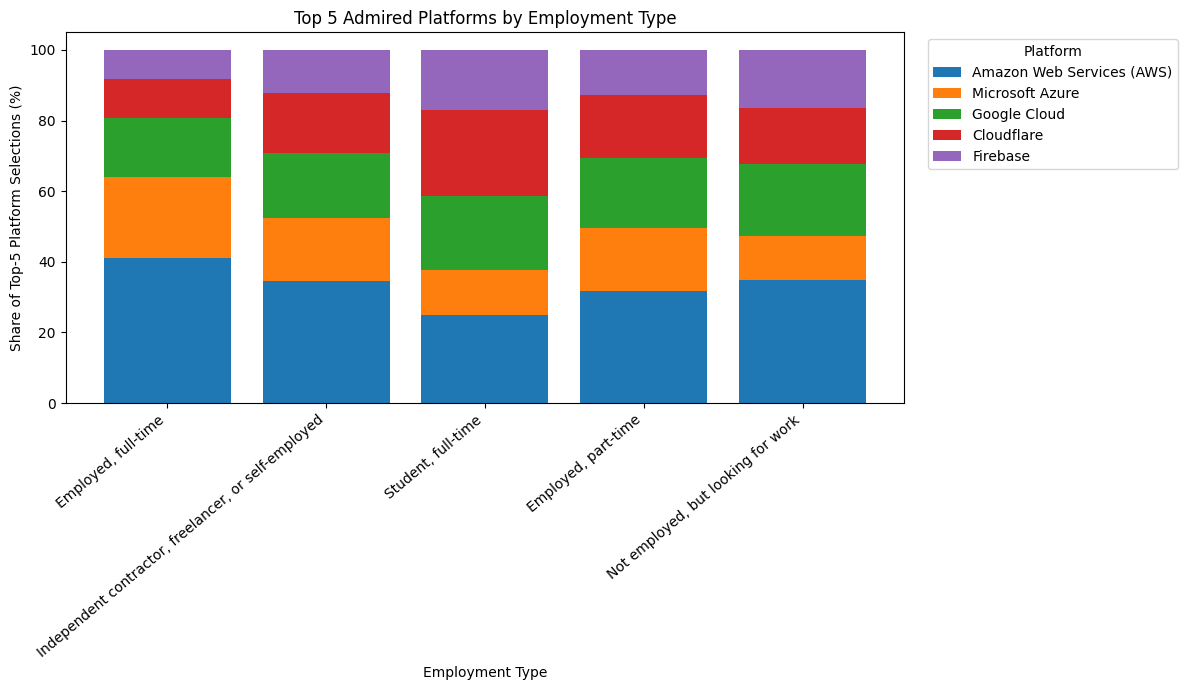

In [14]:
# Task 4.2 - Admired Platforms by Employment Type

platform_employment = df[
    ["Employment", "PlatformAdmired"]
].dropna().copy()

platform_employment["EmploymentType"] = (
    platform_employment["Employment"]
    .str.split(";")
)

platform_employment = platform_employment.explode(
    "EmploymentType",
    ignore_index=True
)

platform_employment["EmploymentType"] = (
    platform_employment["EmploymentType"]
    .str.strip()
)

platform_employment["Platform"] = (
    platform_employment["PlatformAdmired"]
    .str.split(";")
)

platform_employment = platform_employment.explode(
    "Platform",
    ignore_index=True
)

platform_employment["Platform"] = (
    platform_employment["Platform"]
    .str.strip()
)

top_employment = (
    platform_employment["EmploymentType"]
    .value_counts()
    .head(5)
    .index
)

top_platforms = (
    platform_employment["Platform"]
    .value_counts()
    .head(5)
    .index
)

platform_employment = platform_employment[
    platform_employment["EmploymentType"].isin(top_employment)
    &
    platform_employment["Platform"].isin(top_platforms)
]

platform_counts = pd.crosstab(
    platform_employment["EmploymentType"],
    platform_employment["Platform"]
).reindex(
    index=top_employment,
    columns=top_platforms,
    fill_value=0
)

platform_pct = (
    platform_counts
    .div(platform_counts.sum(axis=1), axis=0)
    .mul(100)
    .fillna(0)
)

display(platform_pct.round(2))

x = np.arange(len(platform_pct))
bottom = np.zeros(len(platform_pct))

plt.figure(figsize=(12, 7))

for platform in platform_pct.columns:
    values = platform_pct[platform].to_numpy()
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=platform
    )
    bottom += values

plt.xticks(
    x,
    platform_pct.index,
    rotation=40,
    ha="right"
)

plt.title("Top 5 Admired Platforms by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Share of Top-5 Platform Selections (%)")
plt.legend(
    title="Platform",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


#### Analysis

This 100% stacked chart compares the platform-admiration mix across the five most common employment-status selections. Each bar is normalized to 100%, allowing the analysis to focus on how the relative popularity of the leading platforms differs between employment situations rather than on group size.

If the segment proportions are similar across employment types, the leading platforms have broadly consistent appeal across working arrangements. Larger differences would indicate that platform preferences may be associated with the type of work respondents perform, their organizational context, or the technologies commonly used in their roles.

Both `Employment` and `PlatformAdmired` can contain multiple selections. A respondent with several employment statuses or admired platforms can therefore contribute to multiple combinations. The chart should be read as a comparison of selection patterns rather than mutually exclusive respondent percentages.


### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.
